# 1 Imports

In [1]:
import joblib
import pandas as pd
import sys
from pathlib import Path
import torch
import os
import funciones

c:\Users\Jorge\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Audio de entrada

In [2]:
audios = []

audio_español_generado = os.path.join(os.getcwd(),"audios_prueba_pipeline//español_generado.wav")
audios.append(audio_español_generado)
audio_español_real = os.path.join(os.getcwd(),"audios_prueba_pipeline//español_real.wav")
audios.append(audio_español_real)
audio_ingles_generado = os.path.join(os.getcwd(),"audios_prueba_pipeline//ingles_generado.wav")
audios.append(audio_ingles_generado)
audio_ingles_real = os.path.join(os.getcwd(),"audios_prueba_pipeline//ingles_natural.wav")
audios.append(audio_ingles_real)

## Extraer características

In [10]:
a1 = funciones.extract_features(audio_español_generado)
a2 = funciones.extract_features(audio_español_real)
a3 = funciones.extract_features(audio_ingles_generado)
a4 = funciones.extract_features(audio_ingles_real)

df_esp = pd.DataFrame([a1, a2])
df_eng = pd.DataFrame([a3, a4])
df_completo = pd.concat([df_esp, df_eng])

In [19]:
a1

{'filename': 'c:\\Users\\Jorge\\Documents\\Proyectos de programación\\TFG\\Modelos\\audios_prueba_pipeline//español_generado.wav',
 'duration': 3.3375,
 'rms': 0.063180596,
 'zcr': 0.13589099702380952,
 'spectral_centroid': 1721.172870093517,
 'spectral_bandwidth': 1301.6224252156821,
 'spectral_rolloff': 2923.8839285714284,
 'spectral_flatness': 0.2611892,
 'pitch': array([264.66550794, 255.65002913, 255.65002913, 255.65002913,
        254.17759331, 300.52885649, 307.55338552, 312.929324  ,
        341.2518476 , 361.54373842, 335.38934512, 309.33502416,
        290.29174037, 267.74077301, 257.13099468, 252.7136381 ,
        245.51937138, 234.43211036, 222.55627687, 218.73289324,
        214.97519306, 206.45635927, 200.57894748, 198.27510177,
        197.13312122, 197.13312122, 195.99771799, 205.26725814,
        231.73942791, 237.15608027, 238.52991147, 238.52991147,
        238.52991147, 238.52991147, 216.22053168, 214.97519306,
        213.73702705, 210.06515286, 192.63059451, 189.3

In [21]:
dfa1 = pd.DataFrame.from_dict(a1)

ValueError: All arrays must be of the same length

In [ ]:
df['pitch'] = df['pitch'].apply(lambda x: np.array(json.loads(x)))
df['f1'] = df['f1'].apply(lambda x: json.loads(x))
df['f2'] = df['f2'].apply(lambda x: json.loads(x))
df['f3'] = df['f3'].apply(lambda x: json.loads(x))
for col in df.columns:
    if 'mfcc' in col and not col.endswith('mean'):
        df[col] = df[col].apply(lambda x: np.array(json.loads(x)))
        
df = df.drop(['pitch', 'f1', 'f2', 'f3'], axis=1)
mfcc_cols = [c for c in df.columns if c.startswith('mfcc') and not c.endswith('mean')]
df = df.drop(mfcc_cols, axis=1)

In [15]:
df_esp.drop("filename", axis=1, inplace=True)

In [ ]:
df_esp

## Extraer gráficas

# Cargar modelos

In [5]:
modelo_rf = joblib.load('Jorge/modelo_Random_Forest.pkl')
modelo_lgbm = joblib.load('Jorge/modelo_LightGBM.pkl')
modelo_svm = joblib.load('Jorge/modelo_SVM.pkl')

## Cargar datos de entrenamiento

In [6]:
X_train = pd.read_csv('datos_entrenamiento.csv')

# Random Forest

## Generar predicciones

In [17]:
y_pred_rf = modelo_rf.predict(a1)
y_pred_proba_rf = modelo_rf.predict_proba(a1)[:, 1]

c:\Users\Jorge\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


TypeError: float() argument must be a string or a real number, not 'dict'

## Generar explicaciones

### SHAP
Hay que ver bien cómo hacer esta función para que funcione ya que usa X_train y X_test (de donde los sacamos)

In [ ]:
funciones.explica_shap(modelo=modelo_rf, )

# LightGBM

## Generar predicciones

In [ ]:
y_pred_lgbm = modelo_lgbm.predict(df)
y_pred_proba_lgbm = modelo_lgbm.predict_proba(df)[:, 1]

# Support Vector Machine

## Generar predicciones

In [ ]:
y_pred_svm = modelo_svm.predict(df)
y_pred_proba_svm = modelo_svm.predict_proba(df)[:, 1]

# WAV2VEC2

Cosas que necesita el modelo

In [3]:
import pandas as pd

import tensorflow as tf

from transformers import (
    Wav2Vec2FeatureExtractor,
    Wav2Vec2ForSequenceClassification,
)
import os
    
import funciones_wav2vec2

## Generar predicciones

In [4]:
base = os.getcwd()

model = Wav2Vec2ForSequenceClassification.from_pretrained(
    os.path.join(base,"Iván\wav2vec2-deepfake-final") # Poner ruta donde esté el modelo
)
model.eval()

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    os.path.join(base,"Iván//wav2vec2-deepfake-final") # Poner ruta donde esté el modelo
)

for audio in audios:
    funciones_wav2vec2.generar_predicciones(model, feature_extractor, audio)

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]


nombre = español_generado
Salida del modelo = tensor([[ 0.5250, -0.5362]])
score = 0.2570866346359253

nombre = español_real
Salida del modelo = tensor([[-0.3412,  0.3625]])
score = 0.6690034866333008

nombre = ingles_generado
Salida del modelo = tensor([[-0.3787,  0.4049]])
score = 0.6864721775054932

nombre = ingles_natural
Salida del modelo = tensor([[ 0.5077, -0.5218]])
score = 0.26318100094795227


## Generar explicaciones

100%|██████████| 200/200 [00:02<00:00, 70.83it/s] 


c:\Users\ivire\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


SHAP min: -3.3623975923546823e-06
SHAP max: 9.618337207939476e-05
SHAP std: 2.2680769900234897e-05


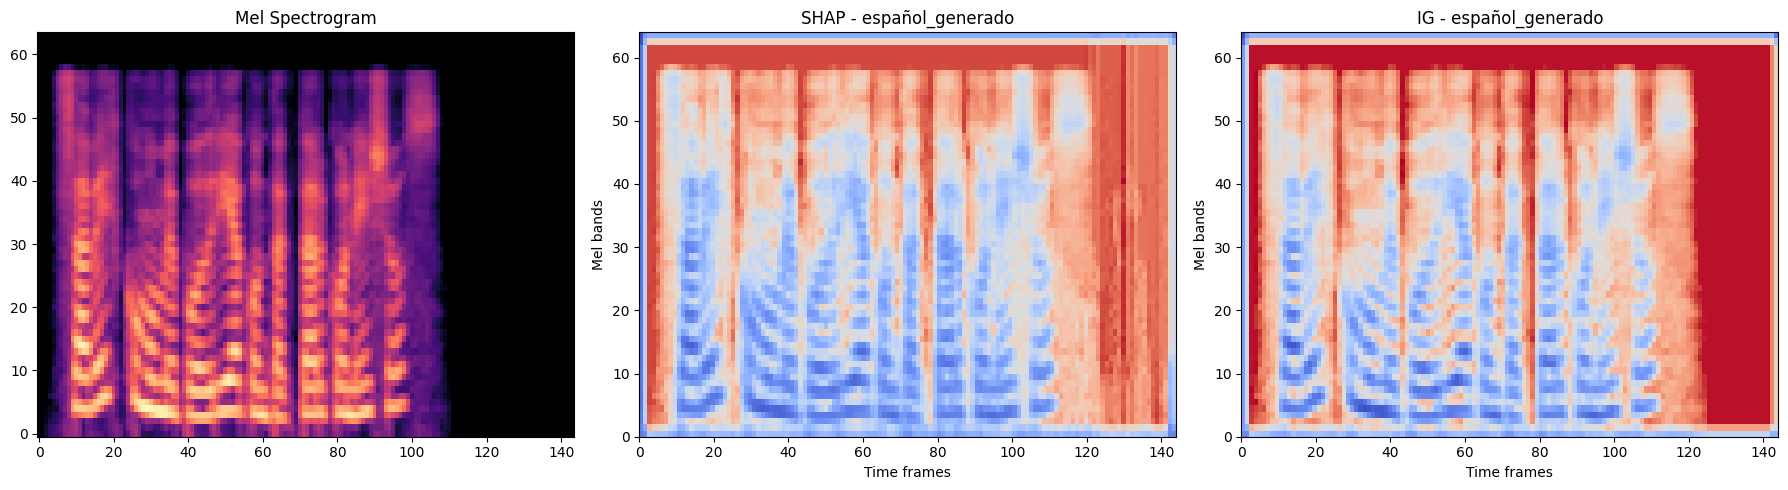

SHAP min: -2.4287519408972003e-06
SHAP max: 7.481735519832e-05
SHAP std: 1.8393187997634717e-05


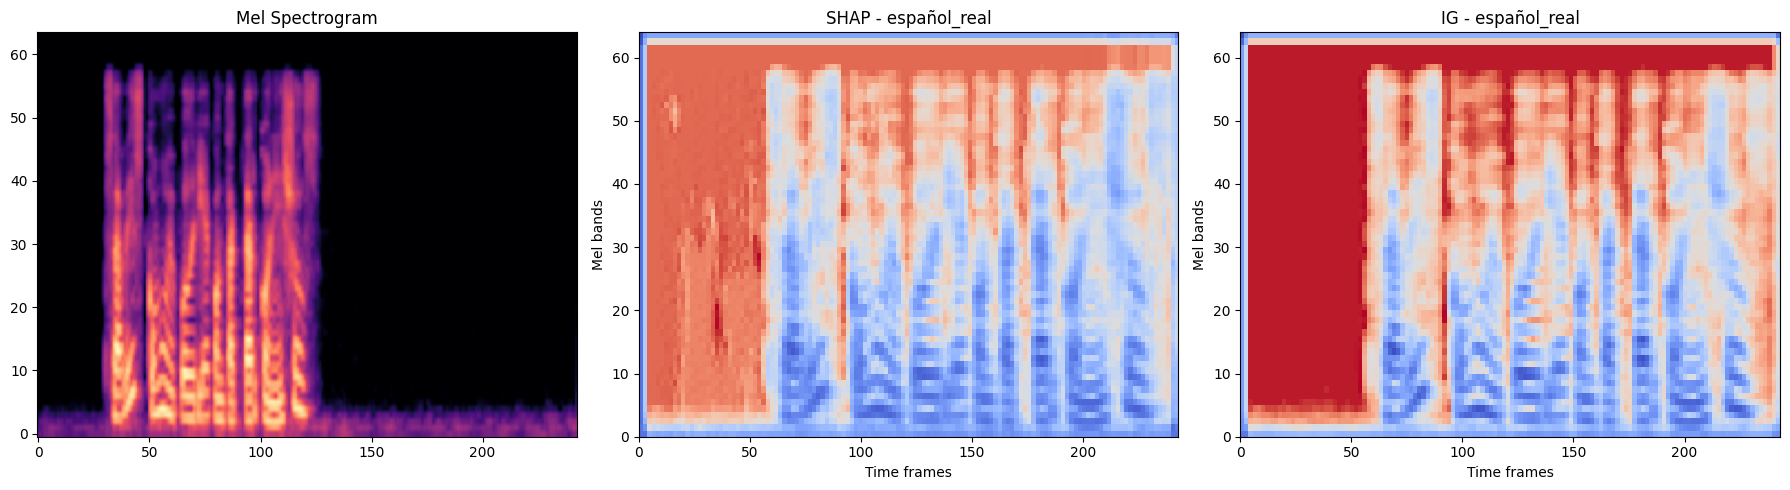

SHAP min: -6.025647962815128e-06
SHAP max: 0.00016615256026852876
SHAP std: 4.4534926418448205e-05


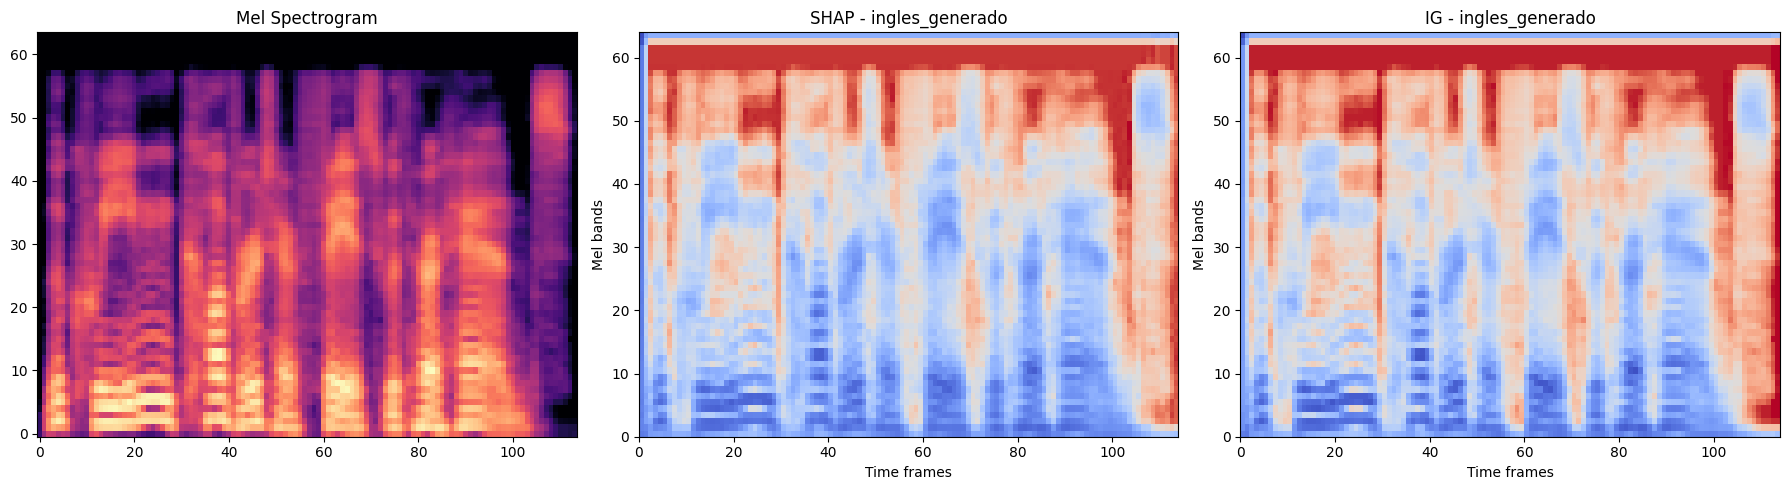

SHAP min: -2.40672147810983e-06
SHAP max: 6.940557796042413e-05
SHAP std: 2.063435790857464e-05


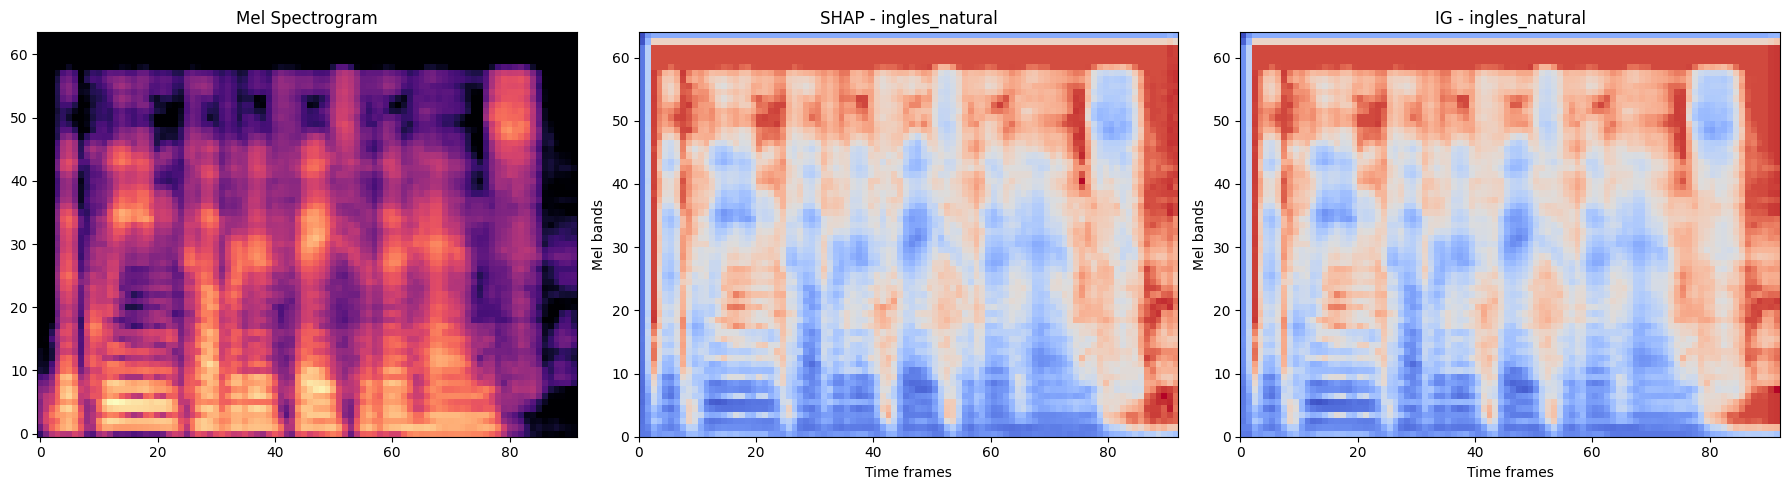

In [5]:
base = os.getcwd()


df_train = pd.read_csv("datos_entrenamiento_espectrogramas.csv")
X_tensor = funciones_wav2vec2.preprocesamiento(df_train,base)
y = df_train["salida_wav2vec2"]
y_tensor = tf.convert_to_tensor(y, dtype=tf.float32)

model_espectrogramas = funciones_wav2vec2.build_surrogate()
model_espectrogramas.fit(X_tensor,y_tensor,epochs=50,batch_size=4,verbose=0)

for audio in audios:
    funciones_wav2vec2.mostrar_graficas(model_espectrogramas,audio,X_tensor)

## AASIST

{'logits': tensor([[ 3.9811, -4.0616]]), 'score_bonafide': -4.06155252456665, 'prob_bonafide': 0.0003213507297914475, 'pred_clase': 'spoof'}


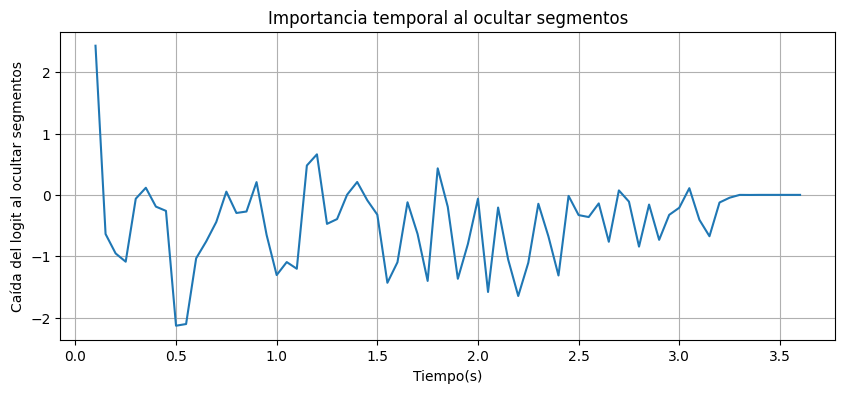

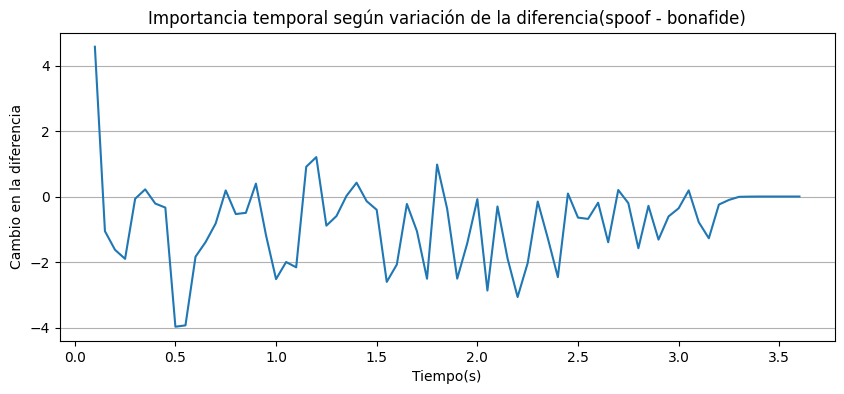

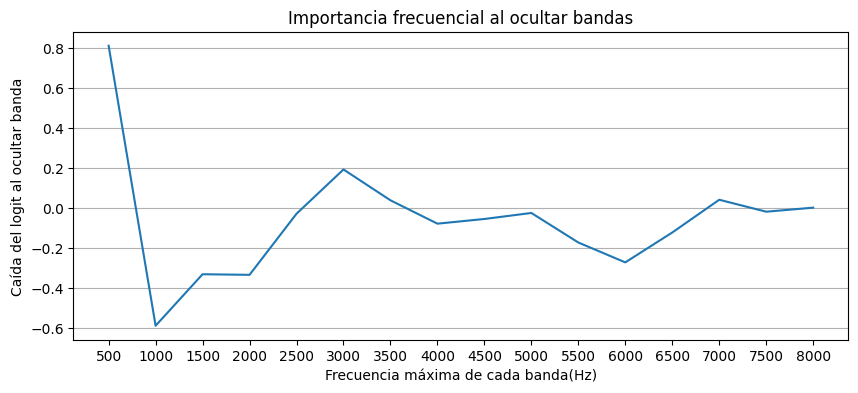

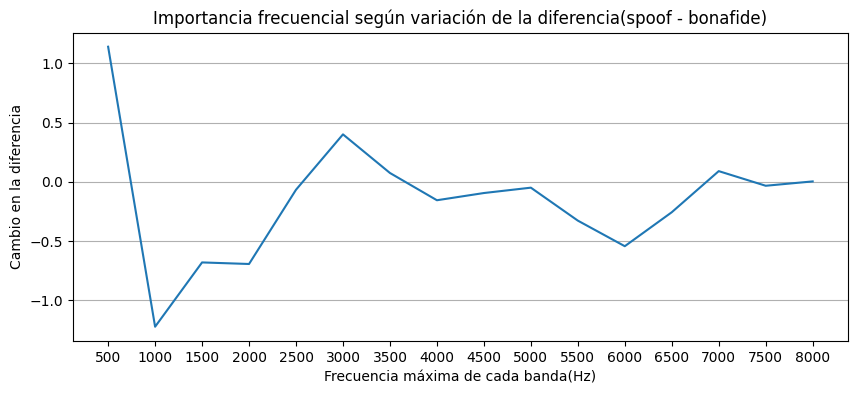

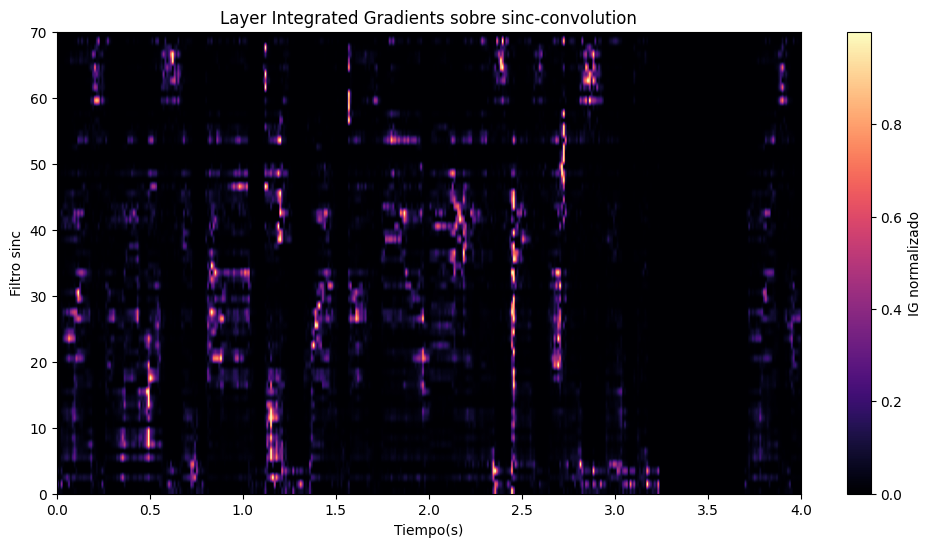

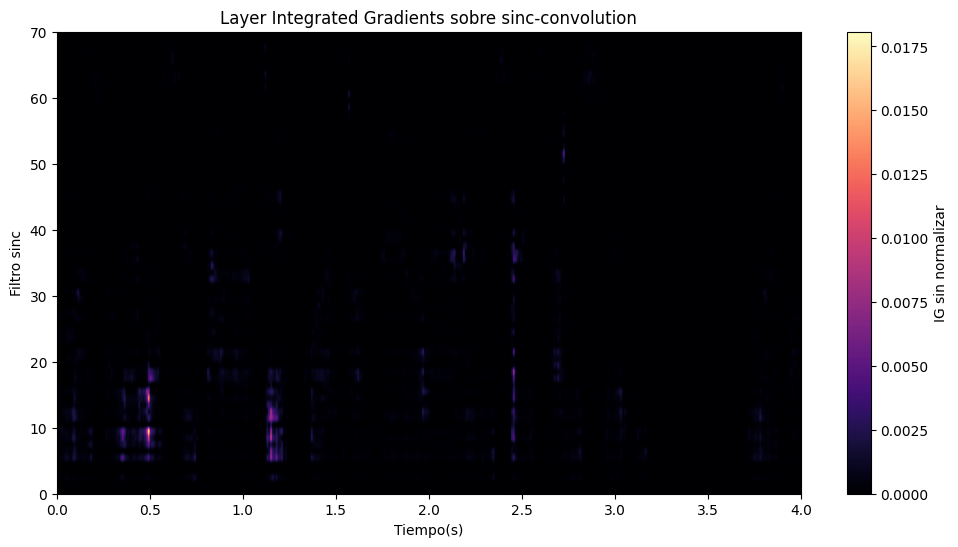

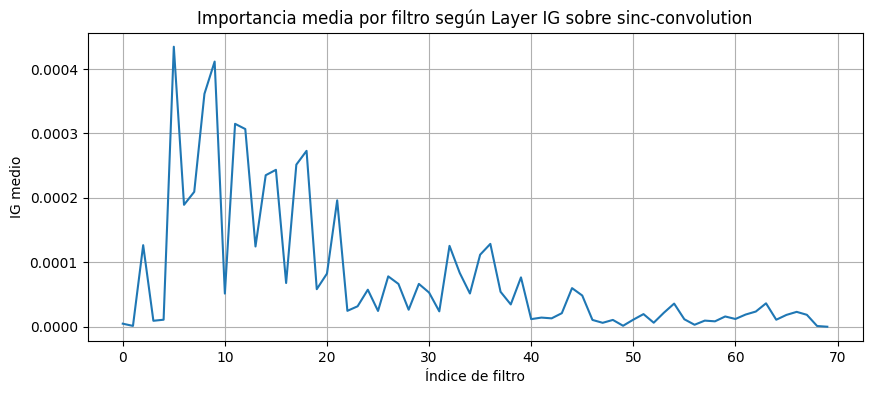

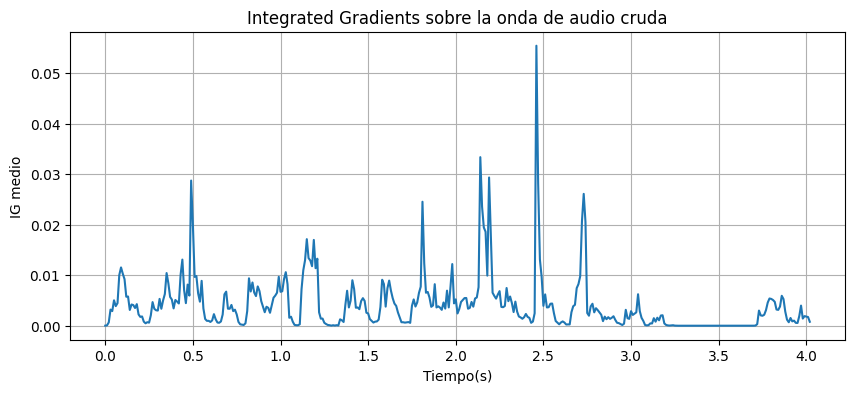

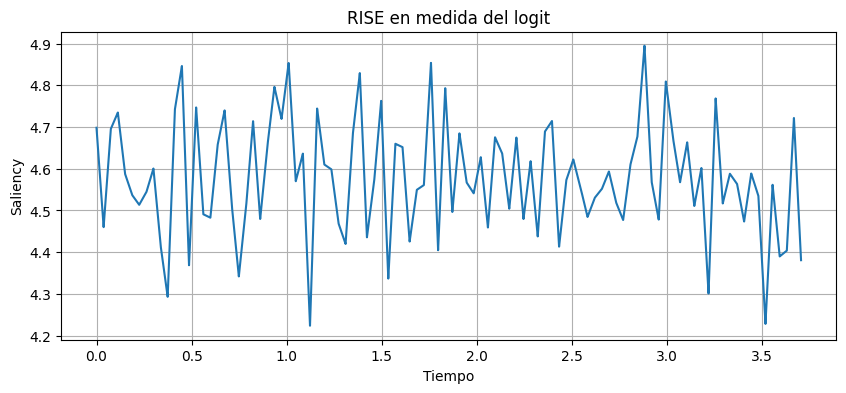

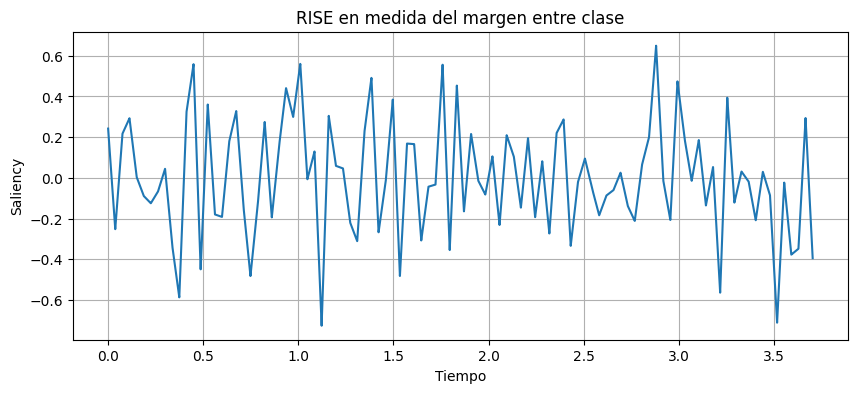

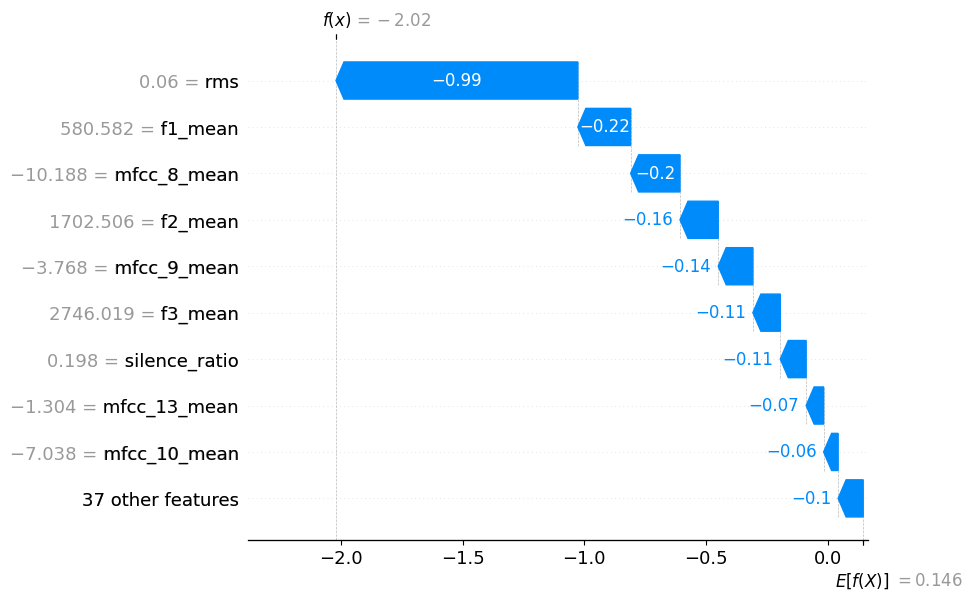

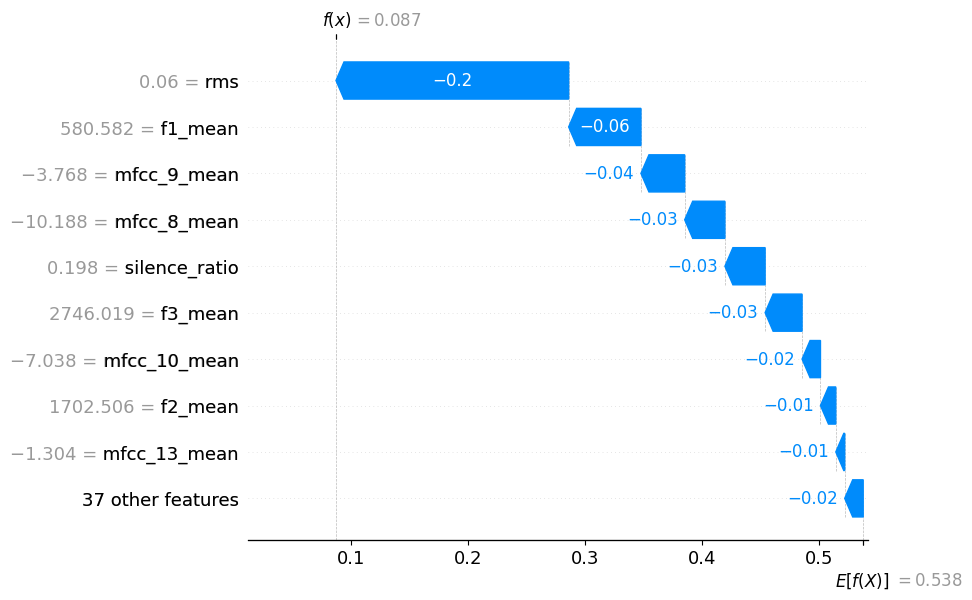

In [ ]:
sys.path.insert(0, str((Path.cwd() / "German").resolve()))
from funciones_aasist import *
from AASIST import Model

model = torch.load("German/aasist_full.pt", map_location="cpu", weights_only=False)
model.eval()

audio = r"C:\TFG\Datasets\Propio\Generado\Español\E_1_G.wav"
res = score_audio(audio, model) 
print(res)
aplicar_XAI(wav_path = audio, model = model, df = df) 